In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [4]:
df = pd.read_csv("loanapproval.csv")

df.head()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   applicant_id          1000 non-null   int64 
 1   age                   1000 non-null   int64 
 2   gender                1000 non-null   object
 3   marital_status        1000 non-null   object
 4   annual_income         1000 non-null   int64 
 5   loan_amount           1000 non-null   int64 
 6   credit_score          1000 non-null   int64 
 7   num_dependents        1000 non-null   int64 
 8   existing_loans_count  1000 non-null   int64 
 9   employment_status     1000 non-null   object
 10  loan_approved         1000 non-null   int64 
dtypes: int64(8), object(3)
memory usage: 86.1+ KB


In [5]:
df.isnull().sum()
df.describe()

,applicant_id,age,annual_income,loan_amount,credit_score,num_dependents,existing_loans_count,loan_approved
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,500.500000,42.515000,81972.972000,27244.866000,576.125000,1.97700,2.042000,0.729000
std,288.819436,12.611059,37547.255418,12822.752877,155.921483,1.41862,1.413589,0.444699
min,1.000000,21.000000,20155.000000,5082.000000,300.000000,0.00000,0.000000,0.000000
25%,250.750000,32.000000,48913.250000,16587.500000,443.750000,1.00000,1.000000,0.000000
50%,500.500000,43.000000,82050.000000,27041.500000,573.500000,2.00000,2.000000,1.000000
75%,750.250000,53.000000,113556.000000,37939.250000,713.250000,3.00000,3.000000,1.000000
max,1000.000000,64.000000,149951.000000,49864.000000,849.000000,4.00000,4.000000,1.000000


In [6]:
df.isnull().sum()

applicant_id            0
age                     0
gender                  0
marital_status          0
annual_income           0
loan_amount             0
credit_score            0
num_dependents          0
existing_loans_count    0
employment_status       0
loan_approved           0
dtype: int64

In [7]:
df["loan_approved"] = df["loan_approved"].map({0:"No", 1:"Yes"})
classes_count = df["loan_approved"].value_counts()
classes_count


loan_approved
Yes    729
No     271
Name: count, dtype: int64

Text(0.5, 1.0, 'Is Loan approved or not?')

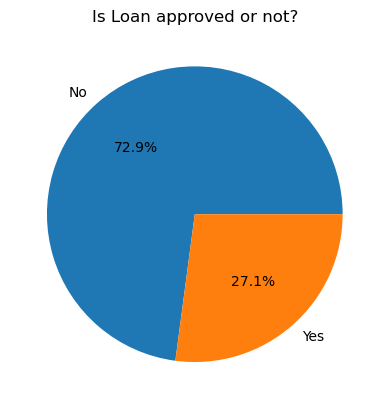

In [8]:
plt.pie(classes_count, labels=["No", "Yes"], autopct="%1.1f%%")
plt.title("Is Loan approved or not?")

<Axes: xlabel='annual_income', ylabel='Count'>

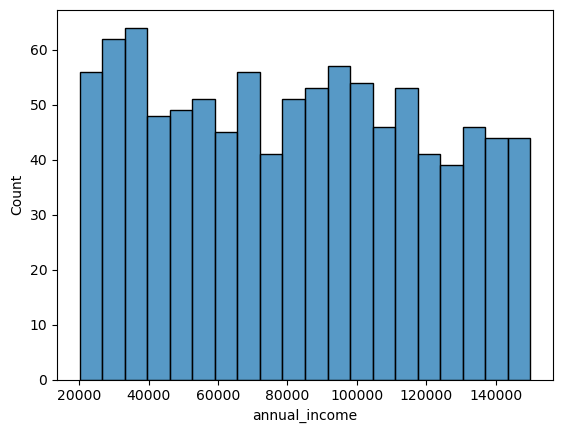

In [9]:
# analyze income

sns.histplot(
    data=df,
    x = "annual_income",
    bins=20
)

<Axes: xlabel='existing_loans_count', ylabel='Count'>

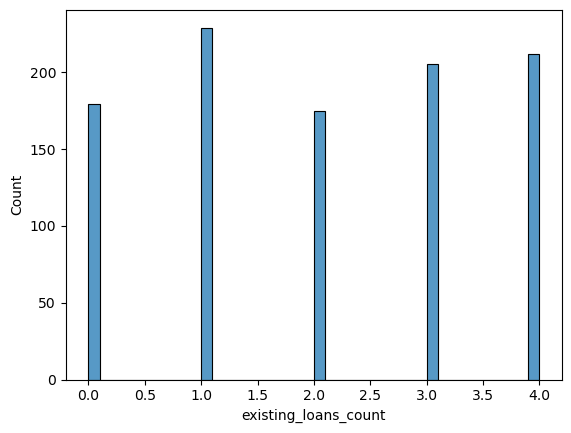

In [10]:
sns.histplot(
    data= df,
    x = "existing_loans_count",
    bins = 40
)

<Axes: xlabel='loan_approved', ylabel='annual_income'>

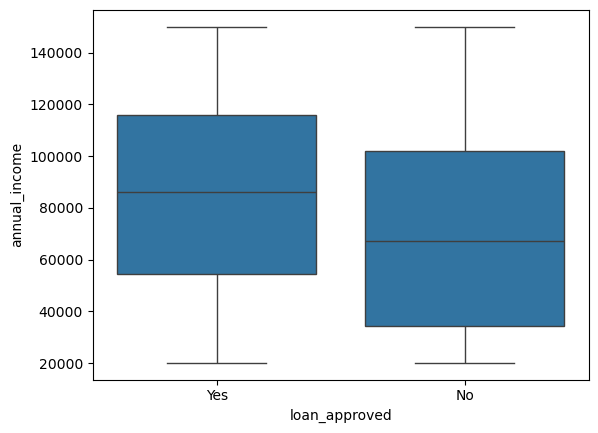

In [12]:
# outliers - box plots

sns.boxplot(
    data = df,
    x = "loan_approved",
    y = "annual_income"
)

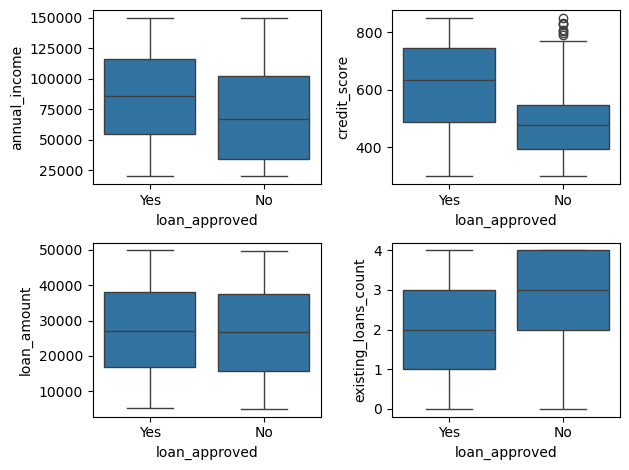

In [16]:
fig, axes = plt.subplots(2,2)

sns.boxplot(ax=axes[0,0], data = df, x="loan_approved", y = "annual_income" )
sns.boxplot(ax=axes[0, 1], data=df, x="loan_approved",y="credit_score")
sns.boxplot(ax=axes[1, 0], data=df, x="loan_approved",y="loan_amount")
sns.boxplot(ax=axes[1, 1], data=df, x="loan_approved",y="existing_loans_count")

plt.tight_layout()





<Axes: xlabel='credit_score', ylabel='Count'>

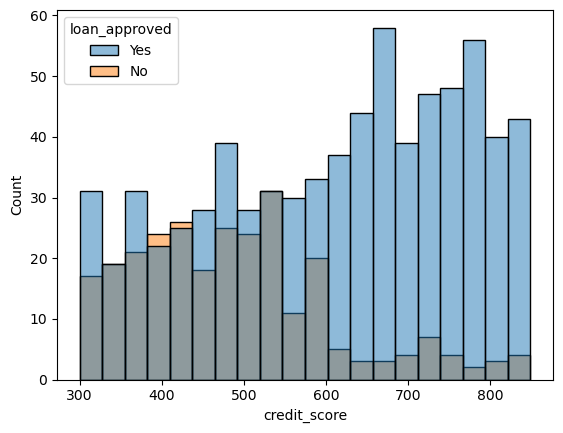

In [17]:
# Credit Score with Loan Approved

sns.histplot(
    data =df,
    hue = "loan_approved",
    x = "credit_score",
    bins = 20
)

<Axes: xlabel='annual_income', ylabel='Count'>

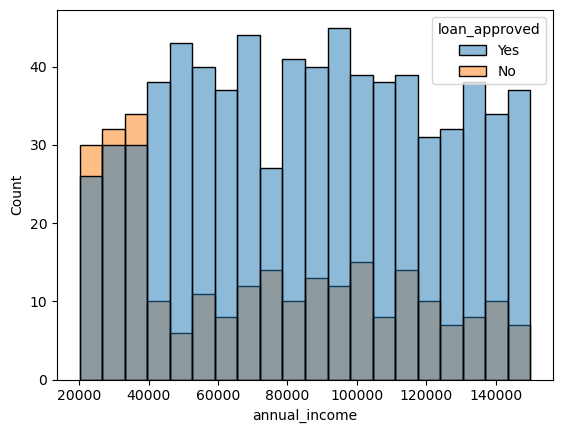

In [18]:
sns.histplot(
    data =df,
    hue = "loan_approved",
    x = "annual_income",
    bins = 20
)

In [19]:
df = df.drop(columns = ["applicant_id"], axis =1)
df.head()

,age,gender,marital_status,annual_income,loan_amount,credit_score,num_dependents,existing_loans_count,employment_status,loan_approved
0,59,Male,Divorced,100073,7169,793,1,1,Unemployed,Yes
1,49,Male,Married,112197,23556,789,0,2,Employed,Yes
2,35,Male,Divorced,84429,27052,372,1,4,Unemployed,No
3,63,Female,Single,124195,11313,808,3,4,Self-employed,Yes
4,28,Female,Married,81627,13315,689,0,1,Unemployed,Yes


In [20]:
#Encoding

df.head()
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   age                   1000 non-null   int64 
 1   gender                1000 non-null   object
 2   marital_status        1000 non-null   object
 3   annual_income         1000 non-null   int64 
 4   loan_amount           1000 non-null   int64 
 5   credit_score          1000 non-null   int64 
 6   num_dependents        1000 non-null   int64 
 7   existing_loans_count  1000 non-null   int64 
 8   employment_status     1000 non-null   object
 9   loan_approved         1000 non-null   object
dtypes: int64(6), object(4)
memory usage: 78.3+ KB


In [24]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

le = LabelEncoder()
df["existing_loans_count"]= le.fit_transform(df["existing_loans_count"])
df["loan_approved"]= le.fit_transform(df["loan_approved"])
df.head()

,age,gender,marital_status,annual_income,loan_amount,credit_score,num_dependents,existing_loans_count,employment_status,loan_approved
0,59,Male,Divorced,100073,7169,793,1,1,Unemployed,1
1,49,Male,Married,112197,23556,789,0,2,Employed,1
2,35,Male,Divorced,84429,27052,372,1,4,Unemployed,0
3,63,Female,Single,124195,11313,808,3,4,Self-employed,1
4,28,Female,Married,81627,13315,689,0,1,Unemployed,1


In [27]:
cols = ["gender","marital_status","employment_status"]

ohe = OneHotEncoder(drop= "first",  sparse_output =False, handle_unknown= "ignore")

encoded = ohe.fit_transform(df[cols])

encoded_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(cols), index=df.index)
df = pd.concat([df.drop(columns=cols), encoded_df ], axis=1)

In [29]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              1000 non-null   int64  
 1   annual_income                    1000 non-null   int64  
 2   loan_amount                      1000 non-null   int64  
 3   credit_score                     1000 non-null   int64  
 4   num_dependents                   1000 non-null   int64  
 5   existing_loans_count             1000 non-null   int64  
 6   loan_approved                    1000 non-null   int64  
 7   gender_Male                      1000 non-null   float64
 8   marital_status_Married           1000 non-null   float64
 9   marital_status_Single            1000 non-null   float64
 10  employment_status_Self-employed  1000 non-null   float64
 11  employment_status_Unemployed     1000 non-null   float64
dtypes: float64(5), int64(

In [30]:
#Train test split

X = df.drop("loan_approved", axis=1)
y = df["loan_approved"]
y.head()


0    1
1    1
2    0
3    1
4    1
Name: loan_approved, dtype: int64

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_test.head()

,age,annual_income,loan_amount,credit_score,num_dependents,existing_loans_count,gender_Male,marital_status_Married,marital_status_Single,employment_status_Self-employed,employment_status_Unemployed
521,57,68781,39064,572,2,4,0.0,1.0,0.0,1.0,0.0
737,34,26796,25238,689,1,2,0.0,0.0,1.0,0.0,1.0
740,59,63056,28749,687,4,3,0.0,1.0,0.0,1.0,0.0
660,37,79871,42044,732,4,1,0.0,0.0,1.0,0.0,1.0
411,46,148734,18767,348,3,0,1.0,0.0,1.0,0.0,0.0


In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled

array([[ 0.33275925,  0.01372064, -0.07570696, ..., -0.72174272,
        -0.73581643, -0.69982706],
       [ 1.04243537,  0.2645305 , -0.0568871 , ..., -0.72174272,
        -0.73581643,  1.42892445],
       [ 0.41161215,  1.38681569,  0.64605787, ..., -0.72174272,
        -0.73581643,  1.42892445],
       ...,
       [ 0.88472957, -0.08296025,  0.10160409, ..., -0.72174272,
        -0.73581643,  1.42892445],
       [ 0.41161215, -1.68388054,  1.25863643, ..., -0.72174272,
        -0.73581643, -0.69982706],
       [ 1.51555279, -0.74401722, -1.51379285, ..., -0.72174272,
         1.35903462, -0.69982706]], shape=(800, 11))

In [33]:
#Train & Evaluation Models

# Logistic regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)

y_pred = log_model.predict(X_test_scaled)

# Evaluation
print("Logistic Regression Model")
print("Precision: ", precision_score(y_test, y_pred))
print("Recall: ", recall_score(y_test, y_pred))
print("F1 score: ", f1_score(y_test, y_pred))
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("CM: ", confusion_matrix(y_test, y_pred))

Logistic Regression Model
Precision:  0.8993288590604027
Recall:  0.9241379310344827
F1 score:  0.9115646258503401
Accuracy:  0.87
CM:  [[ 40  15]
 [ 11 134]]


In [34]:
# KNN

from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

y_pred = knn_model.predict(X_test_scaled)

# Evaluation
print("KNN Model")
print("Precision: ", precision_score(y_test, y_pred))
print("Recall: ", recall_score(y_test, y_pred))
print("F1 score: ", f1_score(y_test, y_pred))
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("CM: ", confusion_matrix(y_test, y_pred))

KNN Model
Precision:  0.8888888888888888
Recall:  0.9379310344827586
F1 score:  0.912751677852349
Accuracy:  0.87
CM:  [[ 38  17]
 [  9 136]]


In [35]:
# Naive Bayes

from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)

y_pred = nb_model.predict(X_test_scaled)

# Evaluation
print("Naive Bayes Model")
print("Precision: ", precision_score(y_test, y_pred))
print("Recall: ", recall_score(y_test, y_pred))
print("F1 score: ", f1_score(y_test, y_pred))
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("CM: ", confusion_matrix(y_test, y_pred))

Naive Bayes Model
Precision:  0.8930817610062893
Recall:  0.9793103448275862
F1 score:  0.9342105263157895
Accuracy:  0.9
CM:  [[ 38  17]
 [  3 142]]


In [37]:
#Feature engineering

# Add or Tranform features
df["annual_income_sq"] = df["annual_income"] ** 2
df["credit_score_sq"] = df["credit_score"] ** 2

# df["Applicant_Income_log"] = np.log1p(df["Applicant_Income"])

X = df.drop(columns=["loan_approved", "credit_score", "annual_income"])
y = df["loan_approved"]

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [38]:
X_train.head()

,age,loan_amount,num_dependents,existing_loans_count,gender_Male,marital_status_Married,marital_status_Single,employment_status_Self-employed,employment_status_Unemployed,annual_income_sq,credit_score_sq
29,47,26300,1,4,1.0,0.0,0.0,0.0,0.0,6996653316,183184
535,56,26542,4,4,0.0,1.0,0.0,0.0,1.0,8640446116,90601
695,48,35581,2,3,1.0,1.0,0.0,0.0,1.0,18118236816,108241
557,59,48463,4,4,1.0,0.0,1.0,0.0,1.0,810654784,157609
836,55,43811,1,2,1.0,1.0,0.0,1.0,0.0,1527715396,108241


In [39]:
# Logistic regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)

y_pred = log_model.predict(X_test_scaled)

# Evaluation
print("Logistic Regression Model")
print("Precision: ", precision_score(y_test, y_pred))
print("Recall: ", recall_score(y_test, y_pred))
print("F1 score: ", f1_score(y_test, y_pred))
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("CM: ", confusion_matrix(y_test, y_pred))

Logistic Regression Model
Precision:  0.9054054054054054
Recall:  0.9241379310344827
F1 score:  0.9146757679180887
Accuracy:  0.875
CM:  [[ 41  14]
 [ 11 134]]


In [40]:
# KNN

from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

y_pred = knn_model.predict(X_test_scaled)

# Evaluation
print("KNN Model")
print("Precision: ", precision_score(y_test, y_pred))
print("Recall: ", recall_score(y_test, y_pred))
print("F1 score: ", f1_score(y_test, y_pred))
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("CM: ", confusion_matrix(y_test, y_pred))

KNN Model
Precision:  0.8734177215189873
Recall:  0.9517241379310345
F1 score:  0.9108910891089109
Accuracy:  0.865
CM:  [[ 35  20]
 [  7 138]]


In [41]:
# Naive Bayes

from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)

y_pred = nb_model.predict(X_test_scaled)

# Evaluation
print("Naive Bayes Model")
print("Precision: ", precision_score(y_test, y_pred))
print("Recall: ", recall_score(y_test, y_pred))
print("F1 score: ", f1_score(y_test, y_pred))
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("CM: ", confusion_matrix(y_test, y_pred))

Naive Bayes Model
Precision:  0.9032258064516129
Recall:  0.9655172413793104
F1 score:  0.9333333333333333
Accuracy:  0.9
CM:  [[ 40  15]
 [  5 140]]
